In [ ]:
import pandas as pd 
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split

data = pd.read_csv("student_performance_dataset.csv")

data



,Study_Hours,Attendance,Assignments_Completed,Previous_Marks,Final_Marks
0,6,83,0,84,47
1,3,100,9,68,66
2,10,90,5,44,61
3,7,56,4,33,36
4,4,53,10,54,47
...,...,...,...,...,...
495,9,69,2,75,55
496,7,82,4,72,60
497,9,69,10,50,60
498,9,98,7,52,63


In [ ]:
data.columns


Index(['Study_Hours', 'Attendance', 'Assignments_Completed', 'Previous_Marks',
       'Final_Marks'],
      dtype='str')

In [ ]:
data.isnull().sum()


Study_Hours              0
Attendance               0
Assignments_Completed    0
Previous_Marks           0
Final_Marks              0
dtype: int64

In [ ]:
data.head()


,Study_Hours,Attendance,Assignments_Completed,Previous_Marks,Final_Marks
0,6,83,0,84,47
1,3,100,9,68,66
2,10,90,5,44,61
3,7,56,4,33,36
4,4,53,10,54,47


In [ ]:
X= data[["Study_Hours", "Attendance", "Attendance", "Previous_Marks"]]
y= data["Final_Marks"]

X_train, X_test, y_train , y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

print(X_train)
print(X_test)


     Study_Hours  Attendance  Attendance  Previous_Marks
249            6          63          63              40
433            4          83          83              76
19             1          84          84              75
322            0          92          92              36
332            0          57          57              89
..           ...         ...         ...             ...
106            7          71          71              87
270            7          61          61              51
348            6          67          67              69
435            6          57          57              94
102            9          57          57              57

[400 rows x 4 columns]
     Study_Hours  Attendance  Attendance  Previous_Marks
361            9          98          98              89
73             6          80          80              49
374            7          66          66              52
155            6          69          69              51
104    

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)




In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean absolute error : ", round(mae, 2))
print("Mean squared error : ", round(mse, 2))
print(" root Mean squared error : ", round(rmse, 2))
print("r2 score : ", round(r2, 2))

Mean absolute error :  5.06
Mean squared error :  38.97
 root Mean squared error :  6.24
r2 score :  0.69


In [ ]:
studyhours = float(input("Enter the study hours : "))
attendance = float(input("Enter the attendance : "))
assignments = float(input("Enter the completion of the assignments : "))
marks = float(input("Enter the previous marks: "))

results = model.predict([[studyhours, attendance, assignments, marks]])
print("Predicted marks : ", results[0])

Predicted marks :  33.21962493792853


c:\Users\ayush\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


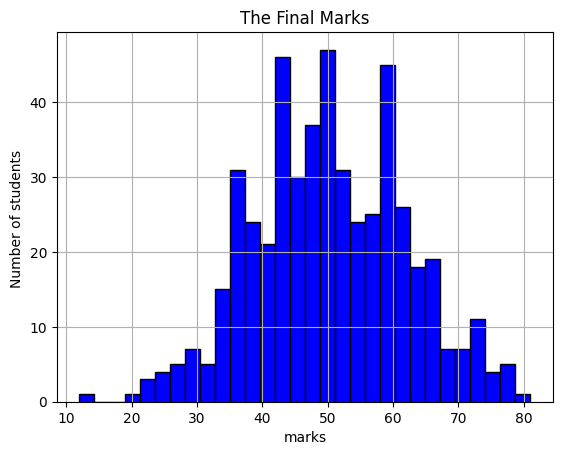

In [ ]:
plt.Figure(figsize=(10,6))
plt.hist(data["Final_Marks"], bins=30, color= "blue", edgecolor= "black")
plt.grid(True)
plt.title("The Final Marks")
plt.xlabel("marks")
plt.ylabel("Number of students ")
plt.show()

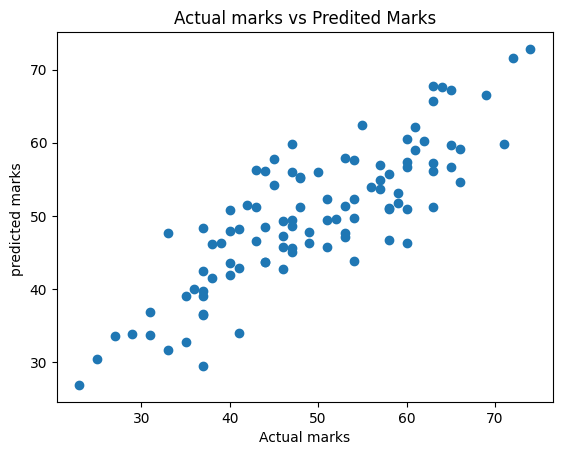

In [ ]:
plt.scatter(y_test, y_pred)
plt.title("Actual marks vs Predited Marks")
plt.xlabel("Actual marks")
plt.ylabel("predicted marks ")
plt.show()

In [ ]:
print(data.corr(numeric_only=True)["Final_Marks"].sort_values(ascending = False))

Final_Marks              1.000000
Study_Hours              0.704604
Assignments_Completed    0.390201
Previous_Marks           0.366733
Attendance               0.269313
Name: Final_Marks, dtype: float64


In [ ]:
import joblib 
joblib.dump(model , "student_performance.pkl")

['student_performance.pkl']

In [ ]:
model = joblib.load("student_performance.pkl")

res = model.predict([[10, 9, 3, 80]])
print("The final marks is : ", res[0])

The final marks is :  53.198239538073274


c:\Users\ayush\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
